In [923]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from lime.lime_tabular import LimeTabularExplainer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt

Zadanie 1. Klasyfikacja za pomocą klasycznego modelu ML

2. Przygotowanie danych.

In [924]:
data = pd.read_csv('diabetes.csv')
data.head()
data.info()
data.isnull().sum()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


3. Podział zbioru na macierz cech (X) oraz wektor wartości docelowych (y).

In [925]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

4. Podziału zbioru na zbiór treningowy i testowy. Zbiór testowy, będzie stanowił 30% całego
zbioru danych. Stratyfikacja względem etykiet. Zarodek liczb losowych = 101.

In [926]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=101
)

5. Zbudowanie modelu regresji logistycznej.

In [927]:
model = LogisticRegression(random_state=101)
model.fit(X_train, y_train)

c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=101)

6. Wytrenowanie modelu.

In [928]:
model.fit(X_train, y_train)

c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=101)

7. Wypróbowanie modelu na zbiorze testowym.

In [929]:
predictions = model.predict(X_test)

8. Ewaluacja modelu na podstawie raportu z klasyfikacji i macierzy błędów.

In [930]:
conf_matrix = confusion_matrix(y_test, predictions)
class_report = classification_report(y_test, predictions)

conf_matrix, class_report

(array([[131,  19],
        [ 38,  43]], dtype=int64),
 '              precision    recall  f1-score   support\n\n           0       0.78      0.87      0.82       150\n           1       0.69      0.53      0.60        81\n\n    accuracy                           0.75       231\n   macro avg       0.73      0.70      0.71       231\nweighted avg       0.75      0.75      0.74       231\n')

Wyjaśnienie klasyfikacji za pomocą algorytmu LIME

2. Stworzenie nazw 2 klas decyzyjnych.

In [931]:
class_names = ['No Diabetes', 'Diabetes']

explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns,
    class_names=class_names,
    mode='classification'
)

3. Stworzenie listy z nazwami kolumn.

In [932]:
feature_names = X.columns.tolist()

4. Stworzenie wyjaśnienia z wykorzystaniem klasy LimeTabularExplainer. W tym celu należy
stworzyć obiekt explainer, który będzie trenowany na zestawie uczącym.

In [933]:
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification'
)

5. Wyjaśnienie lokalnie wyników dla 4 różnych przypadków klasyfikacji (wyświetlenie
etykiety rzeczywistej, etykiety przewidzianej oraz indeks obserwacji): TN, FP, FN i TP,
uwzględniając prawdopodobieństwo i cechy mające największy wpływ na predykcję.

c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, 

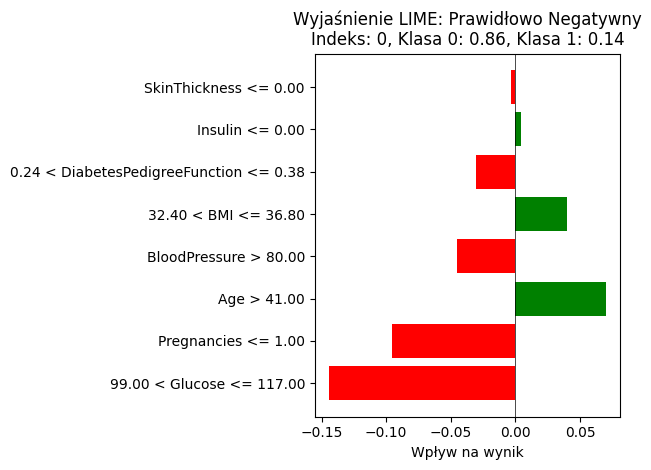

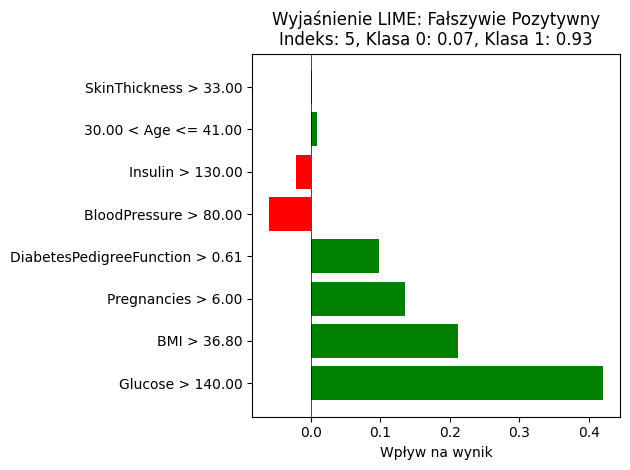

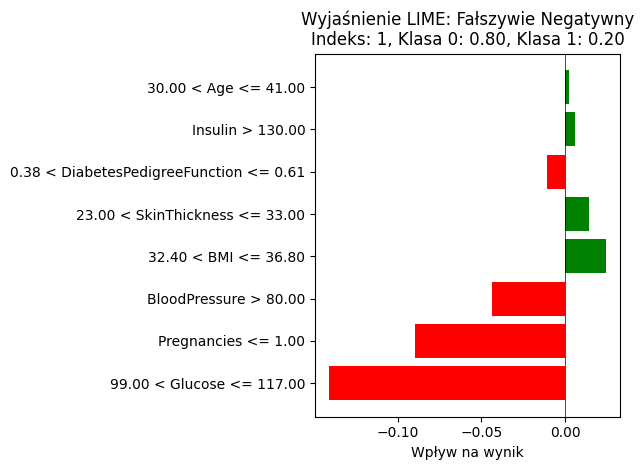

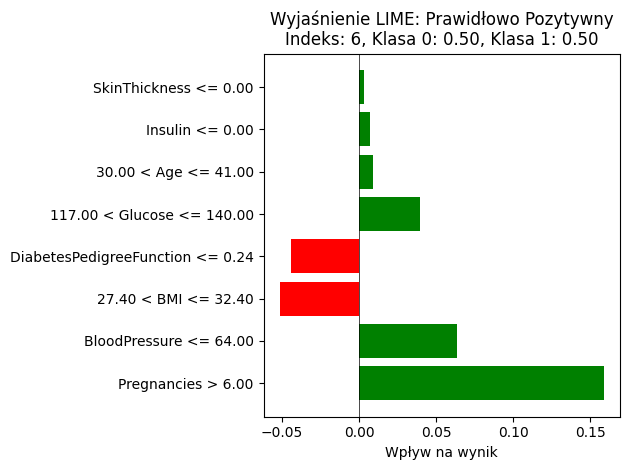

In [934]:
case_conditions = [
    ((y_test.values == 0) & (predictions == 0), "Prawidłowo Negatywny"),
    ((y_test.values == 0) & (predictions == 1), "Fałszywie Pozytywny"),
    ((y_test.values == 1) & (predictions == 0), "Fałszywie Negatywny"),
    ((y_test.values == 1) & (predictions == 1), "Prawidłowo Pozytywny")
]

results = {
    name: {
        "Index": np.where(condition)[0][0],  
        "Probabilities": model.predict_proba([X_test.iloc[np.where(condition)[0][0]]])[0],
        "Explanation": explainer.explain_instance(X_test.iloc[np.where(condition)[0][0]].values, model.predict_proba).as_list()
    }
    for condition, name in case_conditions
}

def draw_explanation(features, title, index, probabilities):
    feature_names, contributions = zip(*features)
    colors = ['green' if c > 0 else 'red' for c in contributions]

    plt.barh(feature_names, contributions, color=colors)
    plt.xlabel('Wpływ na wynik')
    plt.title(f"{title}\nIndeks: {index}, Klasa 0: {probabilities[0]:.2f}, Klasa 1: {probabilities[1]:.2f}")
    plt.axvline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

for name, data in results.items():
    draw_explanation(
        data['Explanation'],
        title=f"Wyjaśnienie LIME: {name}",
        index=data['Index'],
        probabilities=data['Probabilities']
    )


Zadanie 2. Regresja za pomocą klasycznego modelu ML

2. Przygotowanie danych.

In [935]:
housing_data = pd.read_csv('housing.csv')

housing_data_cleaned = housing_data.iloc[:, 0].str.split(expand=True)

column_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]
housing_data_cleaned.columns = column_names

housing_data_cleaned = housing_data_cleaned.apply(pd.to_numeric, errors='coerce')

housing_data_cleaned.head()
housing_data_cleaned.info()
housing_data_cleaned.isnull().sum()
housing_data_cleaned.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     505 non-null    float64
 1   ZN       505 non-null    float64
 2   INDUS    505 non-null    float64
 3   CHAS     505 non-null    int64  
 4   NOX      505 non-null    float64
 5   RM       505 non-null    float64
 6   AGE      505 non-null    float64
 7   DIS      505 non-null    float64
 8   RAD      505 non-null    int64  
 9   TAX      505 non-null    float64
 10  PTRATIO  505 non-null    float64
 11  B        505 non-null    float64
 12  LSTAT    505 non-null    float64
 13  MEDV     505 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.4 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000
mean,3.620667,11.350495,11.154257,0.069307,0.554728,6.284059,68.581584,3.794459,9.566337,408.459406,18.461782,356.594376,12.668257,22.529901
std,8.608572,23.343704,6.855868,0.254227,0.115990,0.703195,28.176371,2.107757,8.707553,168.629992,2.162520,91.367787,7.139950,9.205991
min,0.009060,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082210,0.000000,5.190000,0.000000,0.449000,5.885000,45.000000,2.100000,4.000000,279.000000,17.400000,375.330000,7.010000,17.000000
50%,0.259150,0.000000,9.690000,0.000000,0.538000,6.208000,77.700000,3.199200,5.000000,330.000000,19.100000,391.430000,11.380000,21.200000
75%,3.678220,12.500000,18.100000,0.000000,0.624000,6.625000,94.100000,5.211900,24.000000,666.000000,20.200000,396.210000,16.960000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


3. Podział zbioru na macierz cech (X) oraz wektor wartości docelowych (y).

In [936]:
X = housing_data_cleaned.drop('MEDV', axis=1)
y = housing_data_cleaned['MEDV']

4. Podziału zbioru na zbiór treningowy i testowy. Zbiór testowy, będzie stanowił 10% całego
zbioru danych. Stratyfikacja ze względu na atrybut decyzyjny. Zarodek liczb losowych = 42.

In [937]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

5. Zbudowanie modelu regresji liniowej korzystając z algorytmu regresji opartego na
ekstremalnych drzewa losowych (klasa ExtraTreesRegressor).

In [938]:
model = ExtraTreesRegressor(random_state=42)
model.fit(X_train, y_train)

ExtraTreesRegressor(random_state=42)

6. Wytrenowanie modelu.

In [939]:
model.fit(X_train, y_train)

ExtraTreesRegressor(random_state=42)

7. Wypróbowanie modelu na zbiorze testowym.

In [940]:
predictions = model.predict(X_test)

8. Ewaluacja modelu.

In [941]:
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

mse, mae, r2

(6.144859156862738, 1.7608039215686266, 0.8195359304162103)

Wyjaśnienie regresji za pomocą algorytmu LIME

2. Stworzenie wyjaśnienia z wykorzystaniem klasy LimeTabularExplainer. W tym celu należy
stworzyć obiekt explainer, który będzie trenowany na zestawie uczącym.

In [942]:
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns,
    mode='regression'
)

3. Wyjaśnienie lokalne - jakie parametry wpływają na predykcję w konkretnym przypadku? wyjaśnienie dla 4 przypadków (jaka jest rzeczywista cena domu, jaka jest przewidywana cena domu, jakie cechy wpływają na relatywnie wysoką/niską cenę
domu).

c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(


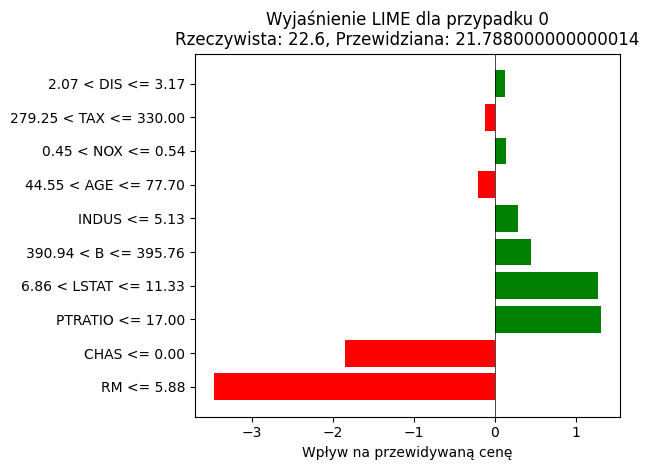

c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(


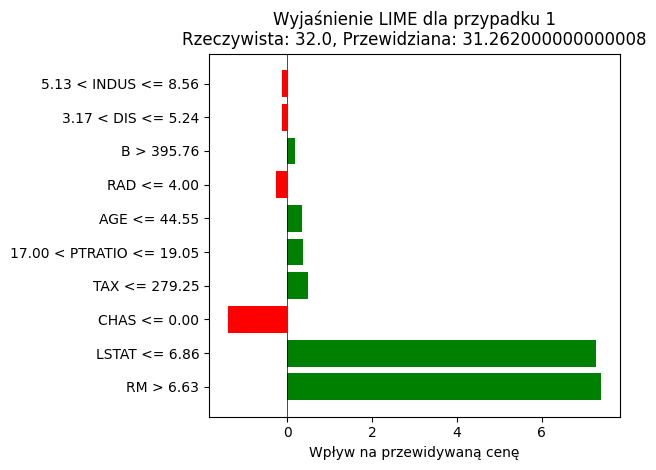

c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(


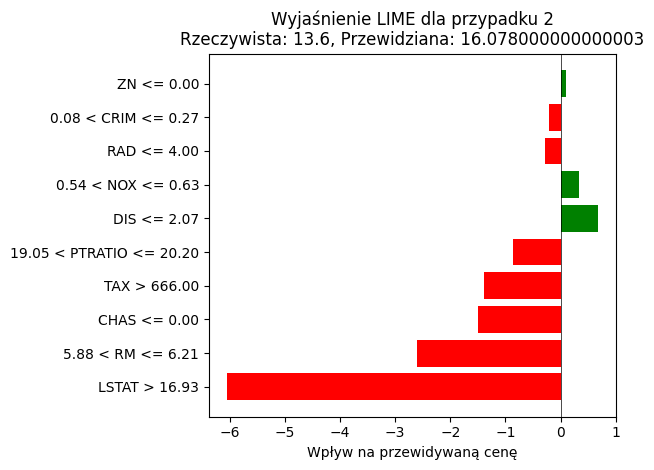

c:\Users\cwiek\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(


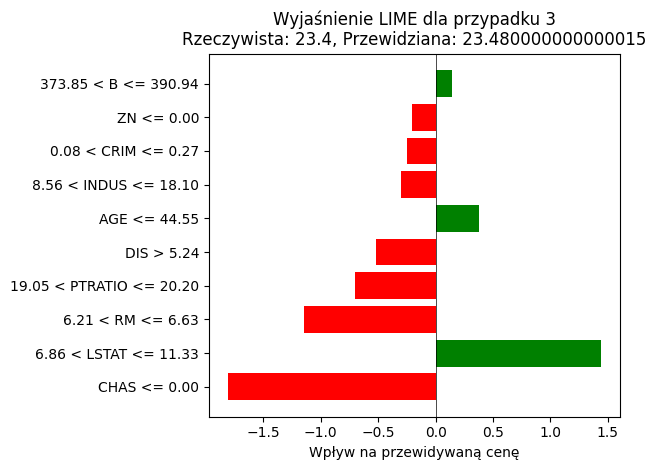

In [ ]:
indices = [0, 1, 2, 3]  
results_with_lime = {}

for idx in indices:
    explanation = explainer.explain_instance(X_test.iloc[idx].values, model.predict)
    
    actual_price = y_test.iloc[idx]
    predicted_price = predictions[idx]
    
    results_with_lime[idx] = {
        "Actual Price": actual_price,
        "Predicted Price": predicted_price,
        "Explanation": explanation.as_list(),
    }

    features, contributions = zip(*explanation.as_list())
    
    colors = ['green' if value > 0 else 'red' for value in contributions]

    plt.barh(features, contributions, color=colors)
    plt.xlabel('Wpływ na przewidywaną cenę')
    plt.title(f"Wyjaśnienie LIME dla przypadku {idx}\nRzeczywista: {actual_price}, Przewidziana: {predicted_price}")
    plt.axvline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()


Zadanie 3. Klasyfikacja tekstu za pomocą klasycznego modelu ML

2. Podział zbioru na macierz cech (X) oraz wektor wartości docelowych (y).

In [944]:
data = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=['Label', 'Message'])

X = data['Message']
y = data['Label']

3. Podziału zbioru na zbiór treningowy i testowy. Zbiór testowy, będzie stanowił 25% całego
zbioru danych. Stratyfikacja względem etykiet. Zarodek liczb losowych = 42

In [945]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

4. Przeprowadzenie transformacji danych tekstowych przy użyciu TF-IDF vectorizer.

In [946]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

5. Zbudowanie modelu lasów losowych.

In [947]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_tfidf, y_train)

RandomForestClassifier(random_state=42)

6. Wytrenowanie modelu.

In [948]:
model.fit(X_train_tfidf, y_train)

RandomForestClassifier(random_state=42)

7. Wypróbowanie modelu na zbiorze testowym.

In [949]:
predictions = model.predict(X_test_tfidf)

8. Ewaluacja modelu na podstawie raportu z klasyfikacji i macierzy błędów.

In [950]:
conf_matrix = confusion_matrix(y_test, predictions)
class_report = classification_report(y_test, predictions)

conf_matrix, class_report

(array([[1206,    0],
        [  38,  149]], dtype=int64),
 '              precision    recall  f1-score   support\n\n         ham       0.97      1.00      0.98      1206\n        spam       1.00      0.80      0.89       187\n\n    accuracy                           0.97      1393\n   macro avg       0.98      0.90      0.94      1393\nweighted avg       0.97      0.97      0.97      1393\n')

Wyjaśnienie klasyfikacji tekstu za pomocą algorytmu LIME

2. Utworzenie wyjaśnienia przy pomocy klasy LimeTextExplainer, dopasowując explainer do
danych treningowych.

In [951]:
explainer = LimeTextExplainer(class_names=model.classes_)

3. Wyjaśnienie lokalnie wyników dla 4 różnych przypadków klasyfikacji wyświetlenie etykiety
rzeczywistej, etykiety przewidzianej oraz indeks obserwacji: True Negative (TN), False
Positive (FP), False Negative (FN), i True Positive (TP), uwzględniając prawdopodobieństwo
i cechy mające największy wpływ na predykcję.

In [952]:
def predict_proba_text(texts):
    texts_tfidf = vectorizer.transform(texts)  
    return model.predict_proba(texts_tfidf) 

Unique labels in y_test: {'ham', 'spam'}
Unique labels in predictions: {'ham', 'spam'}
Selected indices: {'True Negative': 0, 'False Positive': None, 'False Negative': 1, 'True Positive': 8}


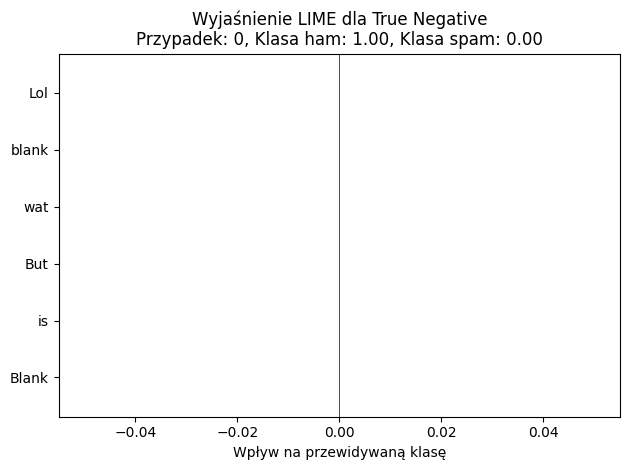

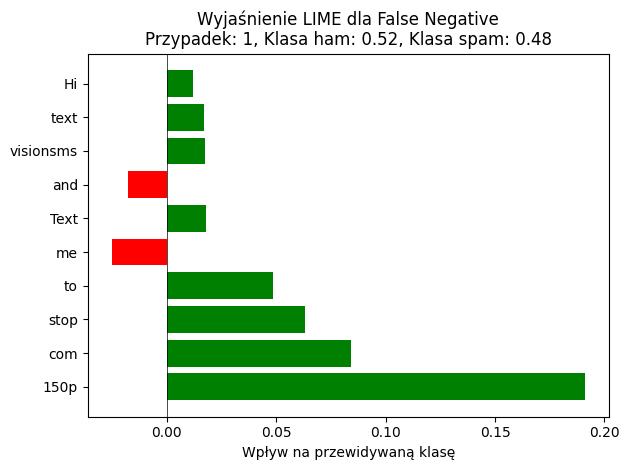

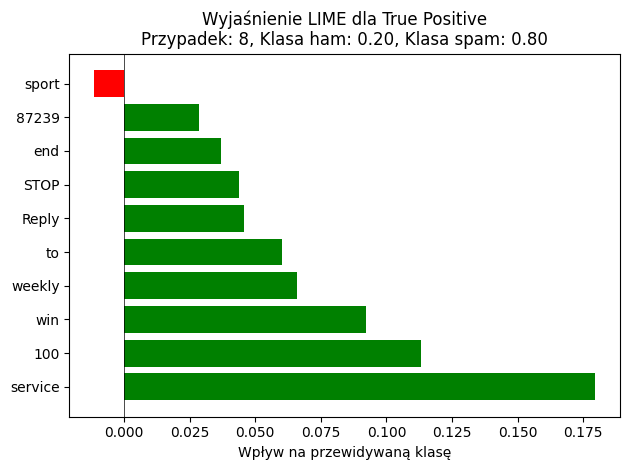

In [953]:
print(f"Unique labels in y_test: {set(y_test.values)}")
print(f"Unique labels in predictions: {set(predictions)}")

def get_first_index(condition):
    indices = np.where(condition)[0]
    return indices[0] if len(indices) > 0 else None

TN_index = get_first_index((y_test.values == 'ham') & (predictions == 'ham'))
FP_index = get_first_index((y_test.values == 'ham') & (predictions == 'spam'))
FN_index = get_first_index((y_test.values == 'spam') & (predictions == 'ham'))
TP_index = get_first_index((y_test.values == 'spam') & (predictions == 'spam'))

selected_indices = {
    "True Negative": TN_index,
    "False Positive": FP_index,
    "False Negative": FN_index,
    "True Positive": TP_index,
}
print(f"Selected indices: {selected_indices}")

selected_indices = {key: idx for key, idx in selected_indices.items() if idx is not None}

results = {}
for case, idx in selected_indices.items():
    explanation = explainer.explain_instance(
        X_test.iloc[idx],  
        predict_proba_text  
    )
    probabilities = model.predict_proba(vectorizer.transform([X_test.iloc[idx]]))[0]
    results[case] = {
        "Index": idx,
        "Actual Label": y_test.iloc[idx],
        "Predicted Label": model.predict(vectorizer.transform([X_test.iloc[idx]]))[0],
        "Probabilities": probabilities,
        "Top Features": explanation.as_list()
    }

def draw_text_explanation(features, title, index, probabilities):
    labels, contributions = zip(*features)
    colors = ['green' if value > 0 else 'red' for value in contributions]

    plt.barh(labels, contributions, color=colors)
    plt.xlabel('Wpływ na przewidywaną klasę')
    plt.title(f"{title}\nPrzypadek: {index}, Klasa ham: {probabilities[0]:.2f}, Klasa spam: {probabilities[1]:.2f}")
    plt.axvline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

for case, data in results.items():
    draw_text_explanation(
        data['Top Features'],
        title=f"Wyjaśnienie LIME dla {case}",
        index=data['Index'],
        probabilities=data['Probabilities']
    )